In [6]:
import numpy as np
import xarray as xr
import pandas as pd

### CPC

In [4]:
pd.read_csv("../input_data/CPC_station_information/cpc_station_list_master.csv")

,wmo_id,stn_call,ghcnd_id,city,state,country,lat,lon,elev,source
0,1001.0,ENJA,JNM00001001,JAN_MAYEN(NOR-NAVY),NaN,NORWAY,70.9394,-8.6690,10.0,cpc+cadb
1,1002.0,NaN,NaN,VERLEGENHUKEN,NaN,NORWAY,80.0555,16.2500,8.0,cpc+cadb
2,1003.0,NaN,NaN,HORNSUND_RIVER,NaN,NORWAY,77.0002,15.5353,12.0,cpc+cadb
3,1004.0,NaN,NOE00134766,NY-ALESUND_I,NaN,NORWAY,78.9250,11.9300,42.0,mixed
4,1005.0,NaN,NOE00111363,ISFJORD_RADIO,NaN,NORWAY,78.0600,13.6300,9.0,cpc
...,...,...,...,...,...,...,...,...,...,...
20738,NaN,TJPS,NaN,MERCEDITA_AIRPORT,PR,PUERTO_RICO,18.0000,-66.5500,9.0,aviation+ncei
20739,NaN,TJVQ,NaN,VIEQUES_ISLAND_DZ,PR,UNITED_STATES,18.1500,-65.3833,NaN,ncei
20740,NaN,TRPG,NaN,JOHN_OSBORNE_APT,NaN,MONTSERRAT,16.7800,-62.2000,170.0,aviation+cadb
20741,NaN,TTCP,NaN,ARTHUR_NAPOLEON_RAYMOND_ROBINSON_INTERNATIONAL...,NaN,TRINIDAD_AND_TOBAGO,11.1500,-60.8330,12.0,ncei


In [28]:
df = pd.read_csv("../input_data/CPC_station_information/cpc_station_list_master.csv")  # columns: station_id, lat, lon, ...
df = df.dropna(subset=["lat", "lon"]).copy()

# Normalize longitudes to [-180, 180)
lon = df["lon"].values % 360
lat = df["lat"].values

# ---- Define 5° bins (edges) ----
lon_edges = np.arange(0, 360+5, 5)   # -180,-175,...,175,180  (length 73)
lat_edges = np.arange(-90,  90  + 5, 5)   #  -90, -85,..., 85, 90  (length 37)

# ---- 2D histogram of station counts per grid box ----
# H shape: (lat_bins-1, lon_bins-1) = (36, 72)
H, yedges, xedges = np.histogram2d(lat, lon, bins=[lat_edges, lon_edges])

# ---- Put into xarray with bin centers as coords ----
lon_centers = (xedges[:-1] + xedges[1:]) / 2.0  #  -177.5,...,177.5  (72)
lat_centers = (yedges[:-1] + yedges[1:]) / 2.0  #   -87.5,..., 87.5  (36)

cpc_count = xr.DataArray(
    H.astype(int),
    dims=("lat", "lon"),
    coords={"lat": lat_centers, "lon": lon_centers},
    name="gauge_count"
)

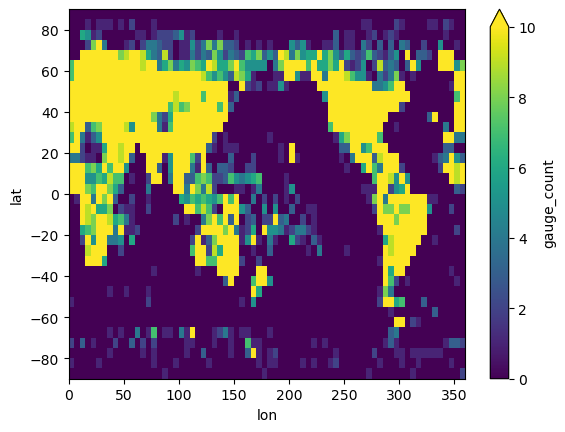

In [46]:
cpc_count.plot(vmin = 0, vmax = 10)

### GPCC: 
Note: numgauge variable is constant over time

In [38]:
gpcc_dat = xr.open_dataset("../input_data/GPCC_Monthly_Precip/v2022/25/full_data_monthly_v2022_2011_2020_25.nc")

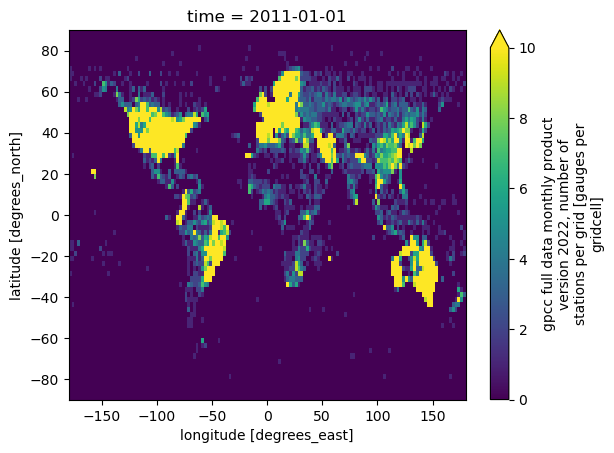

In [39]:
gpcc_dat.numgauge.isel(time = 0).plot(vmin = 0, vmax = 10)

In [42]:
gpcc_count = gpcc_dat.numgauge.isel(time = 0).coarsen(dim = {"lat": 2, "lon": 2}).sum()

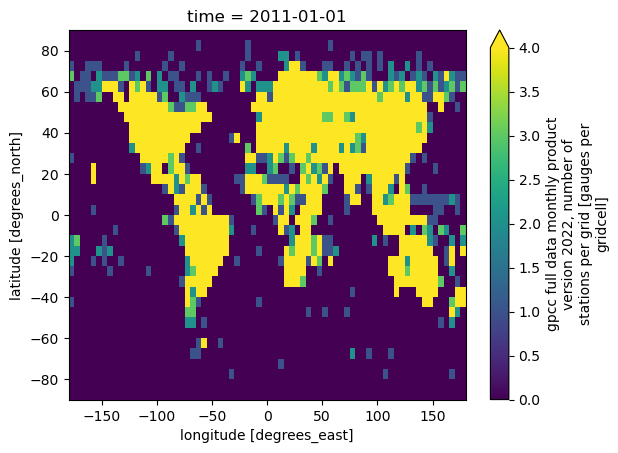

In [66]:
gpcc_count.plot(vmin = 0, vmax = 4)

In [10]:
## create one version of mask as long as each 5x5 cell has a gauge? 
## create one version where each 2.5 cell has gauge? 
## create one version where each 2.5 cell has multiple gauges (4??)

<xarray.DataArray 'numgauge' (lat: 72, lon: 144)> Size: 41kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * lon      (lon) float64 1kB -178.8 -176.2 -173.8 -171.2 ... 173.8 176.2 178.8
  * lat      (lat) float64 576B 88.75 86.25 83.75 81.25 ... -83.75 -86.25 -88.75

### REGEN

In [73]:
regen_all_mask = xr.open_dataset("../input_data/REGEN/AllStns/v1-2019/REGEN_AllStns_V1-2019_1950-2016_QualityMask.nc")

In [74]:
regen_mask = xr.open_dataset("../../DATA/REGEN/LongTermStns/v1-2019/REGEN_LongTermStns_V1-2019_1950-2016_QualityMask.nc")

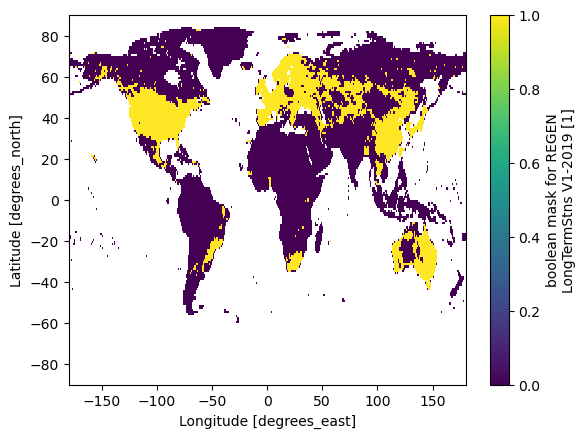

In [75]:
regen_mask.p.plot()

In [76]:
regen_mask_5deg = regen_mask.p.coarsen(dim = {"lat": 5, "lon": 5}).sum()

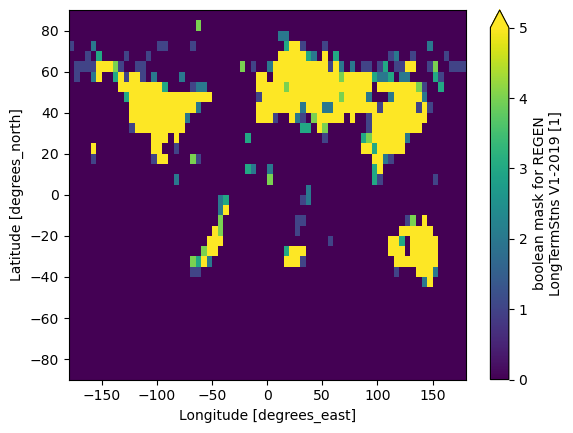

In [77]:
regen_mask_5deg.plot(vmin = 0, vmax = 5)

In [83]:
xr.where(regen_mask_5deg >= 2, 1, np.nan).sum()

<xarray.DataArray 'p' ()> Size: 8B
array(361.)

In [85]:
361/693

0.5209235209235209

In [87]:
regen_mask_5deg.to_netcdf("../mnt_processed_data/regen_LongTerm_quality_mask.nc")